In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

In [8]:
from exact_sync.v1.api.annotations_api import AnnotationsApi
from exact_sync.v1.api.images_api import ImagesApi
from exact_sync.v1.api.image_sets_api import ImageSetsApi
from exact_sync.v1.api.annotation_types_api import AnnotationTypesApi
from exact_sync.v1.api.image_registration_api import ImageRegistrationApi

from exact_sync.v1.models import ImageSet, Team, Product, AnnotationType, Image, Annotation, ImageRegistration
from exact_sync.v1.rest import ApiException
from exact_sync.v1.configuration import Configuration
from exact_sync.v1.api_client import ApiClient

import os, getpass

In [9]:
configuration = Configuration()
configuration.username = 'alha7503'
configuration.password = os.getenv("EXACT_PASSWORD") or getpass.getpass("EXACT password: ")
configuration.host = "https://exact.hs-flensburg.de"

client = ApiClient(configuration)

image_sets_api = ImageSetsApi(client)
annotations_api = AnnotationsApi(client)
annotation_types_api = AnnotationTypesApi(client)
images_api = ImagesApi(client)
image_registration_api = ImageRegistrationApi(client)


In [ ]:
def getAllImageSets():
    return image_sets_api.list_image_sets()
def getImageSetById(id):
    return image_sets_api.list_image_sets(id=id).results[0]
def getDfFromImageSets(image_sets):
    data = image_sets.to_dict() 
    df = pd.DataFrame(data["results"])
    df["n_images"] = df["images"].map(len)
    return df[["id", "name", "path", "n_images", "team", "creator", "product_set"]]

In [89]:
def download_image_set_thumbnails(set_id):
    image_set = getImageSetById(set_id)
    
    safe_name = re.sub(r'[^\w\-]', '_', image_set.name)
    folder_name = f"{image_set.id}_{safe_name}"
    
    save_dir = Path(f"image_sets/{folder_name}/thumbnails")
    save_dir.mkdir(parents=True, exist_ok=True)
    
    for img_id in image_set.images:
        target_path = save_dir / f"{img_id}.png"
        images_api.download_thumbnail(id=img_id, target_path=target_path)

def download_image_set_huge_images(set_id):
    image_set = getImageSetById(set_id)
    
    safe_name = re.sub(r'[^\w\-]', '_', image_set.name)
    folder_name = f"{image_set.id}_{safe_name}"
    
    save_dir = Path(f"image_sets/{folder_name}/huge_images")
    save_dir.mkdir(parents=True, exist_ok=True)
    
    for img_id in image_set.images:
        target_path = save_dir / f"{img_id}_{safe_name}.png"
        
        if not target_path.exists():
            images_api.download_image(id=img_id, target_path=target_path)


In [88]:
image_info = images_api.retrieve_image(id=8864)
image_info

{'annotations': [2026322, 2026422, 2025548],
 'filename': 'MCT_A5356-11_c_VMU_VMU_OVS1_HE_F1.vsi',
 'height': 59450,
 'id': 8864,
 'image_set': 198,
 'image_type': 0,
 'mpp': 0.136915,
 'name': 'MCT_A5356-11_c_VMU_VMU_OVS1_HE_F1.vsi',
 'objective_power': 40.0,
 'time': datetime.datetime(2025, 2, 17, 16, 4, 47, 275380),
 'width': 44710}

In [93]:
import zipfile

fake_png_path = "image_sets/198_VMU1_F1_HE_OVS1/huge_images/8864_VMU1_F1_HE_OVS1.png"

# Let's open it as the ZIP archive it actually is
with zipfile.ZipFile(fake_png_path, 'r') as zip_ref:
    # Print the files contained inside
    print(zip_ref.namelist())
    

['_MCT_A5356-11_c_VMU_VMU_OVS1_HE_F1_/stack1/', '_MCT_A5356-11_c_VMU_VMU_OVS1_HE_F1_/stack1/frame_t.ets', '_MCT_A5356-11_c_VMU_VMU_OVS1_HE_F1_/stack10000/', '_MCT_A5356-11_c_VMU_VMU_OVS1_HE_F1_/stack10000/blob_21_f_Frame#0.ets', '_MCT_A5356-11_c_VMU_VMU_OVS1_HE_F1_/stack10000/frame_t.ets', '_MCT_A5356-11_c_VMU_VMU_OVS1_HE_F1_/stack10000/blob_21_f.meta', '_MCT_A5356-11_c_VMU_VMU_OVS1_HE_F1_/stack10002/', '_MCT_A5356-11_c_VMU_VMU_OVS1_HE_F1_/stack10002/frame_t.ets', '_MCT_A5356-11_c_VMU_VMU_OVS1_HE_F1_/MCT_A5356-11_c_VMU_VMU_OVS1_HE_F1.vsi']


In [92]:
slide_path = "/Users/alexanderhallmann/Desktop/medical-image-registration/image_sets/198_VMU1_F1_HE_OVS1/huge_images/8864_VMU1_F1_HE_OVS1.png" # Adjust path as needed

with tifffile.TiffFile(slide_path) as tif:
    # Page 0 is always the full-resolution baseline image
    page = tif.pages[0]
    
    
    print(f"Data type (Bit depth): {page.dtype}")        # e.g., uint8 (8-bit) or uint16 (16-bit)
    print(f"Shape: {page.shape}")                        # e.g., (100000, 100000, 3)
    print(f"Channels (Samples per pixel): {page.samplesperpixel}") # e.g., 3 (RGB)
    print(f"Bits per sample: {page.bitspersample}")      # e.g., 8

TiffFileError: not a TIFF file: header=b'PK\x03\x04'

In [94]:
import zipfile
from pathlib import Path

fake_png_path = "image_sets/198_VMU1_F1_HE_OVS1/huge_images/8864_VMU1_F1_HE_OVS1.png"
extract_dir = Path("image_sets/198_VMU1_F1_HE_OVS1/huge_images/8864_extracted")

# Extract the beast
with zipfile.ZipFile(fake_png_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)
    

In [95]:
import tifffile

# Find the .vsi file we just extracted
vsi_files = list(extract_dir.rglob("*.vsi"))
vsi_path = vsi_files[0]

# Read the raw metadata
with tifffile.TiffFile(vsi_path) as tif:
    # Page 0 is the highest resolution baseline
    page = tif.pages[0]
    
    print(f"Data type (Bit depth): {page.dtype}")        
    print(f"Shape: {page.shape}")                        
    print(f"Channels: {page.samplesperpixel}") 
    print(f"Photometric: {page.photometric}")

Data type (Bit depth): uint8
Shape: (375, 991, 3)
Channels: 3
Photometric: 2


### Select source and target image

## Calculate transformation matrix between source and target image

In [7]:
thumbnail_size=(1024, 1024)


registration = image_registration_api.register_image(source_image=source_image.id, target_image=target_image.id,thumbnail_size=thumbnail_size)
registration

{'file': '/media/registration/308_307_f1xSAT6.pickle',
 'id': 13,
 'registration_error': 31.16170462409491,
 'runtime': 6,
 'source_image': 308,
 'target_image': 307,
 'transformation_matrix': {'t_00': 1.1184308250596962,
                           't_01': 0.003348072015119987,
                           't_02': 481.70917365984815,
                           't_10': -0.004070912066448941,
                           't_11': 1.1130403342080453,
                           't_12': -1889.3081740883285,
                           't_20': 0,
                           't_21': 0,
                           't_22': 0}}

In [8]:
registration = image_registration_api.retrieve_image_registration(id=13)

## Download Quad-Tree from server

In [11]:
qt_file = "temp.pickle"
status, target_path = image_registration_api.download_registration_file(file=registration.server_file, target_path=qt_file)

qt = pickle.load(open(str(qt_file), "rb" ))
str(qt)

'Source: A_BB_563476_1 \nTarget: N2_BB_563476_1 \nSource: (-0.50, 0.00, 32398.50, 32362.00) Target: (0.00, 0.00, 36864.00, 33792.00)\nx: [1.118, 0.003, 481.709], y: [-0.004, 1.113, -1889.308]] error: 31.162'

## Download source annotation

## Transform source annotation

## Upload transformed annotation

In [130]:
info = image_registration_api.list_image_registrations_with_http_info(limit=4000)

In [129]:
info

({'count': 3054,
  'next': 'http://exact.hs-flensburg.de/api/v1/images/registration/?limit=50&offset=50',
  'previous': None,
  'results': [{'file': 'http://exact.hs-flensburg.de/media/registration/6036_6045_r10tblm.pickle',
               'id': 191,
               'registration_error': 104.38675487149722,
               'runtime': 33,
               'source_image': 6036,
               'target_image': 6045,
               'transformation_matrix': {'t_00': 0.999398059318965,
                                         't_01': -0.00020282846028934223,
                                         't_02': -1243.5138093608236,
                                         't_10': 0.00024455038200216076,
                                         't_11': 0.9999230769021725,
                                         't_12': -32.762125098451975,
                                         't_20': 0.0,
                                         't_21': 0.0,
                                         't_22': 1.0}},


In [131]:
source_images = []
target_images = []
for res in info[0].results:
    source_images.append(res.source_image)
    target_images.append(res.target_image)


In [135]:
target_images.index(8864)

329

In [136]:
target_images[325:334]

[9922, 9921, 9920, 9919, 8864, 9923, 9936, 9941, 6002]

In [109]:
qt_file = "temp.pickle"
status, target_path = image_registration_api.download_registration_file(file=registration.server_file, target_path=qt_file)


NameError: name 'registration' is not defined

In [ ]:
# Validate Download


# Validate Download

In [ ]:
import json
from pathlib import Path

DATASET_DIR = Path("dataset/images")
LABEL_FILE = Path("dataset/labels.json")

downloaded_ids = {int(f.stem) for f in DATASET_DIR.glob("*.data")}

with open(LABEL_FILE, "r") as f:
    labels = json.load(f)

complete_pairs = 0
broken_pairs = []

for pair in labels:
    src = pair["source_image_id"]
    tgt = pair["target_image_id"]

    if src in downloaded_ids and tgt in downloaded_ids:
        complete_pairs += 1
    else:
        broken_pairs.append(pair)




--- Validation Results ---
Valid, complete pairs in labels.json: 8
Broken pairs missing from disk: 0


Successfully opened! The image has 7 pyramidal levels.
Thumbnail shape: (617, 1600, 3)
Successfully opened! The image has 7 pyramidal levels.
Thumbnail shape: (617, 1600, 3)


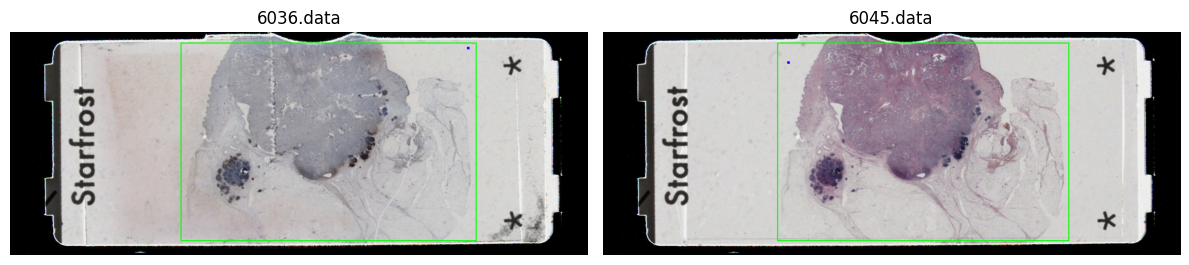

In [17]:
import tifffile
import matplotlib.pyplot as plt
from pathlib import Path

file_paths = [Path("dataset/images/6036.data"), Path("dataset/images/6045.data")]

fig, axes = plt.subplots(1, len(file_paths), figsize=(12, 6))

# Open the BigTIFF safely without loading pixels into memory yet
for ax, file_path in zip(axes, file_paths):
    with tifffile.TiffFile(file_path) as slide:
        print(f"Successfully opened! The image has {len(slide.pages)} pyramidal levels.")
        
        # Grab the smallest level (usually the last page in the pyramid)
        thumbnail = slide.pages[-1].asarray()
    

    print(f"Thumbnail shape: {thumbnail.shape}")

    # Plot it
    ax.imshow(thumbnail)
    ax.set_title(file_path.name)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [10]:
images_api.list_images(id=6045)


{'count': 1,
 'next': None,
 'previous': None,
 'results': [{'annotations': 'Annotations not load please remove '
                             'omit=annotations',
              'filename': 'MAC_1255-24-A_f_FU_FU_AAT2_HE_F1.svs',
              'height': 88842,
              'id': 6045,
              'image_set': 108,
              'image_type': 0,
              'mpp': 0.2525,
              'name': 'MAC_1255-24-A_f_FU_FU_AAT2_HE_F1.svs',
              'objective_power': 40.0,
              'time': datetime.datetime(2024, 12, 12, 14, 8, 12, 921607),
              'width': 131472}]}

In [11]:
images_api.list_images(id=6036)


{'count': 1,
 'next': None,
 'previous': None,
 'results': [{'annotations': 'Annotations not load please remove '
                             'omit=annotations',
              'filename': 'MAC_1255-24-A_f_FU_FU_AAT2_PHH3_F1.svs',
              'height': 88844,
              'id': 6036,
              'image_set': 117,
              'image_type': 0,
              'mpp': 0.2525,
              'name': 'MAC_1255-24-A_f_FU_FU_AAT2_PHH3_F1.svs',
              'objective_power': 40.0,
              'time': datetime.datetime(2024, 12, 12, 13, 35, 14, 835733),
              'width': 133464}]}